In [86]:
"""
Visualize embeddings in 2D space using t-SNE or PCA
Shows how similar/different your product embeddings are
"""

from elasticsearch import Elasticsearch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine
import pandas as pd
from dotenv import load_dotenv
load_dotenv()
import os
# ============================================================================
# constants
# ============================================================================
env = "DEV"
MODEL_ID = "intfloat__e5-small"
MODEL_NAME = "e5"
SEARCH_TYPE = "vector"
#INDEX_RAW = "pp_vs_raw_docs-v1"        # stores original raw documents
INDEX_VECTOR = "pp-vs-e5-llmd-embeddings-no-passage"  # stores documents with vector embeddings
INDEX_NAME = "pp-vs-e5-llmd-embeddings-no-passage"
PIPELINE_ID = f"{MODEL_NAME.lower()}_embedding_base_pipeline"
SHOULD_DELETE_INDEX = False
#CLOUD_ID="dsg-search-dev-east:ZWFzdHVzLmF6dXJlLmVsYXN0aWMtY2xvdWQuY29tOjQ0MyQ1Zjc1NDk5MTVmNmE0ZTBjYWFhYzYzM2IwZDI1MjNlZSRiZTg1OWU2ZGM0ZTg0Y2RmYTVjNDNkNzJiZDA3ZTg3Mg=="
ES_HOST = os.getenv("ELASTIC_HOST_DEV")
ES_USER = os.getenv("ELASTIC_USERNAME")
ES_PASS = os.getenv("ELASTIC_PASSWORD")
INDEX_SETTINGS = { 
    "index": {
        "number_of_replicas": "0",
        "number_of_shards": "1",
        #"knn": True  # Enable kNN search
        # No need for "knn": true — only needed if using legacy knn_vector
    }   
}
#both sbert and e5 small has same dimension.
dims = 384 if MODEL_NAME.lower() == "sbert" else 384  # adjust per model


In [2]:
def get_embedding_column(model_name: str) -> str:
    return "vs_e5_llm_product_desc_embedding" if model_name.lower() == "e5" else "content_embedding"


In [3]:
# ============================================================================
# CONNECT TO ELASTICSEARCH
# ============================================================================

es = Elasticsearch(
    ES_HOST,  # Replace with your actual host
    basic_auth=(ES_USER,ES_PASS),
    request_timeout=600,
    verify_certs=True  # Optional: Set to False only if using self-signed certs
)

# Test connection
print(es.info().body)


{'name': 'instance-0000000097', 'cluster_name': '5f7549915f6a4e0caaac633b0d2523ee', 'cluster_uuid': 'hrds7YuPRLy60DbQMfN9Ow', 'version': {'number': '8.19.3', 'build_flavor': 'default', 'build_type': 'docker', 'build_hash': '1fde05a4d63448377eceb8fd3d51ce16ca3f02a9', 'build_date': '2025-08-26T02:35:34.366492370Z', 'build_snapshot': False, 'lucene_version': '9.12.2', 'minimum_wire_compatibility_version': '7.17.0', 'minimum_index_compatibility_version': '7.0.0'}, 'tagline': 'You Know, for Search'}


**Get embedding from ES for passage:**

In [27]:
def embed_with_elastic(text: str):
    response = es.ml.infer_trained_model(
        model_id=MODEL_ID,
        docs=[{"text_field": text}]
    )
    return response["inference_results"][0]["predicted_value"]

In [207]:
prod_desc1 = "passage: Unisex Feathers & Dubbing. Perfect Hatch Feathers & Dubbing consists of dyed feathers, plumage, and hackle. Assorted feathers are included. Feathers are used for tying flies. Dyed feathers provide variety for fly tying."
prod_desc2 = "passage: Obermeyer Girls' Furry Fleece 1/4 Zip is a Girls' Jacket. It has a flat seam construction, thumbhole cuffs, and a mock neck. The jacket features a 1/4 zip closure with a YKK zipper and an active fit. The center back length is 21 inches. Obermeyer Girls' Furry Fleece 1/4 Zip is made for Skiing and Winter Recreation. It is a fleece jacket with a quarter zip design."
query = f"query: feather coat"
embedding_1 = embed_with_elastic(prod_desc1)
embedding_2 = embed_with_elastic(prod_desc2)
embedding_query = embed_with_elastic(query)


In [208]:
emb = embed_with_elastic("test")
print(np.linalg.norm(emb))

0.9999999852495509


In [209]:
def weighted_embedding(ptype, cat, desc):
    e_type = np.array(embed_with_elastic(f"Product Type: {ptype}"), dtype=np.float32)
    e_cat  = np.array(embed_with_elastic(f"Category: {cat}"), dtype=np.float32)
    e_desc = np.array(embed_with_elastic(f"Description: {desc}"), dtype=np.float32)

    e = 0.5 * e_type + 0.3 * e_cat + 0.2 * e_desc

    return e / np.linalg.norm(e)

e1 = weighted_embedding("Necktie", "Accessories Formalwear", "silk woven red gold stripes")
e2 = weighted_embedding("Jacket", "Apparel Outerwear", "feather filled winter insulation")

print("New cosine:", cosine_similarity(e1, e2))

New cosine: 0.9257943


In [210]:
import numpy as np

def cosine_similarity(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


In [213]:
sim = cosine_similarity(embedding_1, embedding_query)
print(f"Cosine similarity: {sim:.4f}")

Cosine similarity: 0.8348


In [185]:
e_type1 = np.array(embed_with_elastic("passage: Echo Necktie is a unisex neckwear accessory"))
e_type2 = np.array(embed_with_elastic("passage: Light Blue Jacket is a men's outerwear garment"))

e_cat1 = np.array(embed_with_elastic("passage: Category: Accessories Formalwear"))
e_cat2 = np.array(embed_with_elastic("passage: Category: Apparel Outerwear"))

e_desc1 = np.array(embed_with_elastic("passage: silk woven red gold stripes"))
e_desc2 = np.array(embed_with_elastic("passage: feather filled winter insulation"))

print("Type similarity:", cosine_similarity(e_type1, e_type2))
print("Category similarity:", cosine_similarity(e_cat1, e_cat2))
print("Description similarity:", cosine_similarity(e_desc1, e_desc2))


Type similarity: 0.7886993224980994
Category similarity: 0.9046900445033261
Description similarity: 0.7784594637292307


In [92]:
###### ============================================================================
# GET EMBEDDINGS FROM ELASTICSEARCH
# ============================================================================

def get_embeddings_from_es(index_name: str, query_text: str, size: int = 5):
    """
    Fetch embeddings and descriptions from Elasticsearch
    """
    search_field = get_embedding_column(MODEL_NAME)
    print(search_field)
    print("size=",size)
    print(query_text)
    knn_query_body = { 
        "size" : size,
        "knn": {
            "field": search_field,
            "k": size,  # Number of nearest neighbors to retrieve
            "num_candidates": max(50 * size, 1000),# Number of candidates to consider during search
            "query_vector_builder": {
                "text_embedding": {
                    "model_id": MODEL_ID,    # deployed SBERT/E5 model
                    "model_text": query_text      # the query text to embed
                }
            }   
        }   
    }   
    embeddings = []
    descriptions = []

    results = es.search(
        index=INDEX_VECTOR,
        body=knn_query_body
    )   
    for hit in results['hits']['hits']:
        emb = hit['_source']['vs_e5_llm_product_desc_embedding']
        desc = hit['_source']['llm_description'][8:100]
        
        embeddings.append(emb)
        descriptions.append(desc)
    
    return np.array(embeddings), descriptions


In [93]:
# ============================================================================
# VISUALIZATION FUNCTION 1: t-SNE (Better for clustering)
# ============================================================================

def visualize_with_tsne(embeddings, descriptions, title="Embeddings Visualization (t-SNE)"):
    """
    Visualize embeddings using t-SNE
    Good for seeing clusters and groups
    """
    
    print("Computing t-SNE... (this may take a moment)")
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1))
    embeddings_2d = tsne.fit_transform(embeddings)
    
    plt.figure(figsize=(12, 8))
    
    # Plot points
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=100, alpha=0.6, c=range(len(embeddings)), cmap='viridis')
    
    # Add labels
    for i, desc in enumerate(descriptions):
        plt.annotate(desc, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                    fontsize=9, alpha=0.7, xytext=(5, 5), textcoords='offset points')
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("tsne_plot.png", dpi=300, bbox_inches='tight')
    plt.show()



In [94]:
# ============================================================================
# VISUALIZATION FUNCTION 2: PCA (Faster, more interpretable)
# ============================================================================

def visualize_with_pca(embeddings, descriptions, title="Embeddings Visualization (PCA)"):
    """
    Visualize embeddings using PCA
    Faster than t-SNE, shows variance
    """
    
    print("Computing PCA...")
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    
    plt.figure(figsize=(12, 8))
    
    # Plot points
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=100, alpha=0.6, c=range(len(embeddings)), cmap='viridis')
    
    # Add labels
    for i, desc in enumerate(descriptions):
        plt.annotate(desc, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                    fontsize=9, alpha=0.7, xytext=(5, 5), textcoords='offset points')
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.colorbar(scatter, label='Document Index')
    plt.tight_layout()
    plt.savefig("pca_plot.png", dpi=300, bbox_inches='tight')
    plt.show()

In [95]:
# ============================================================================
# SIMILARITY MATRIX HEATMAP
# ============================================================================

def visualize_similarity_matrix(embeddings, descriptions):
    """
    Show a heatmap of pairwise similarities
    Useful for small number of documents
    """
    
    # Calculate similarity matrix
    n = len(embeddings)
    similarity_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            similarity_matrix[i, j] = 1 - cosine(embeddings[i], embeddings[j])
    
    # Plot heatmap
    plt.figure(figsize=(10, 8))
    im = plt.imshow(similarity_matrix, cmap='coolwarm', aspect='auto', vmin=0, vmax=1)
    
    # Add colorbar
    plt.colorbar(im, label='Cosine Similarity')
    
    # Set labels
    short_descs = [d[:20] for d in descriptions]
    plt.xticks(range(n), short_descs, rotation=45, ha='right', fontsize=9)
    plt.yticks(range(n), short_descs, fontsize=9)
    
    # Add values in cells
    for i in range(n):
        for j in range(n):
            text = plt.text(j, i, f'{similarity_matrix[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=10)
    
    plt.title('Embedding Similarity Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
   
    plt.show()


In [96]:
# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

def print_embedding_stats(embeddings, descriptions):
    """
    Print statistics about embeddings
    """
    
    print("=" * 80)
    print("EMBEDDING STATISTICS")
    print("=" * 80)
    
    print(f"\nNumber of embeddings: {len(embeddings)}")
    print(f"Embedding dimensions: {len(embeddings[0])}")
    
    # Norms
    norms = [np.linalg.norm(e) for e in embeddings]
    print(f"\nEmbedding norms:")
    print(f"  Average: {np.mean(norms):.6f}")
    print(f"  Min: {np.min(norms):.6f}")
    print(f"  Max: {np.max(norms):.6f}")
    
    # Pairwise similarities
    similarities = []
    for i in range(len(embeddings)):
        for j in range(i+1, len(embeddings)):
            sim = 1 - cosine(embeddings[i], embeddings[j])
            similarities.append(sim)
    
    print(f"\nPairwise similarities:")
    print(f"  Average: {np.mean(similarities):.6f}")
    print(f"  Min: {np.min(similarities):.6f}")
    print(f"  Max: {np.max(similarities):.6f}")
    
    # Create DataFrame for detailed view
    print(f"\n" + "=" * 80)
    print("PAIRWISE SIMILARITY MATRIX")
    print("=" * 80)
    
    for i in range(len(embeddings)):
        for j in range(i+1, len(embeddings)):
            sim = 1 - cosine(embeddings[i], embeddings[j])
            desc_i = descriptions[i][:35]
            desc_j = descriptions[j][:35]
            print(f"{desc_i:<35} vs {desc_j:<35} = {sim:.6f}")



FETCHING EMBEDDINGS FROM ELASTICSEARCH
vs_e5_llm_product_desc_embedding
size= 32
feather coat

✓ Fetched 32 embeddings
EMBEDDING STATISTICS

Number of embeddings: 32
Embedding dimensions: 384

Embedding norms:
  Average: 1.000000
  Min: 1.000000
  Max: 1.000000

Pairwise similarities:
  Average: 0.861162
  Min: 0.804422
  Max: 0.973678

PAIRWISE SIMILARITY MATRIX
r coat is a winter coat made with r vs ua Metz #1 Hen Neck Hackle Fly Tyin = 0.845276
r coat is a winter coat made with r vs  Adult FC Barcelona Vintage Terrace = 0.833107
r coat is a winter coat made with r vs  Large Featherlight Tote is a unise = 0.822547
r coat is a winter coat made with r vs s of Melanin Men's Grambling State  = 0.839919
r coat is a winter coat made with r vs hell & Ness Youth Philadelphia Phil = 0.841397
r coat is a winter coat made with r vs ect Hatch Peacock Herl is a type of = 0.841469
r coat is a winter coat made with r vs  Outdoors Featherlight Waterproof G = 0.827274
r coat is a winter coat made wit

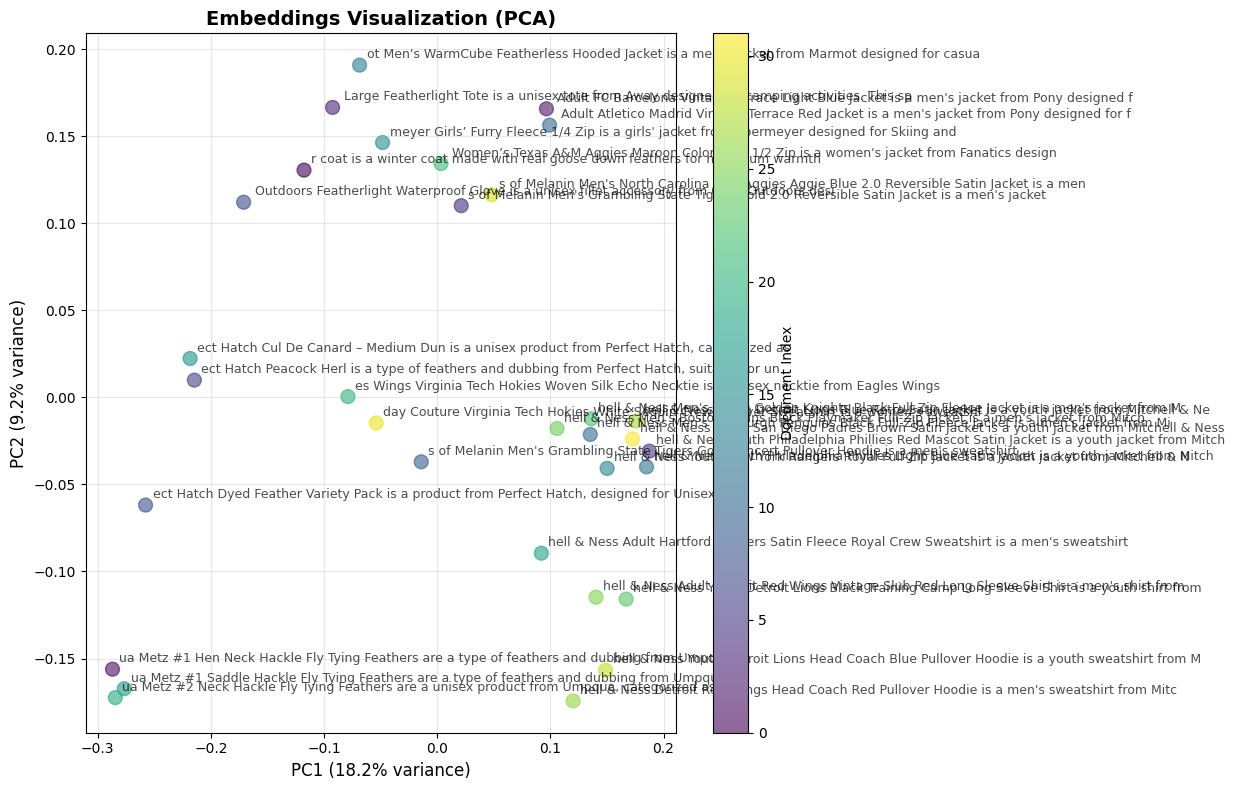


VISUALIZATION 2: t-SNE (Better clustering)
Computing t-SNE... (this may take a moment)


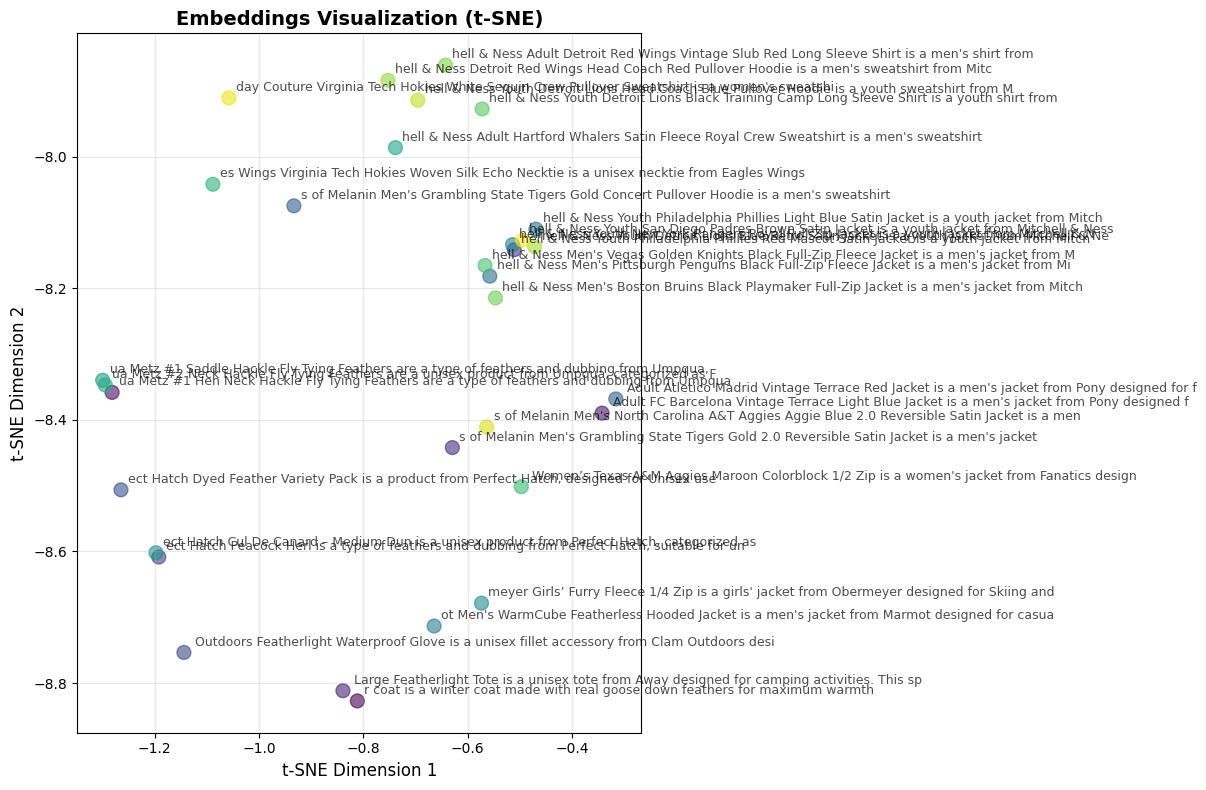

In [97]:
# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    
    print("=" * 80)
    print("FETCHING EMBEDDINGS FROM ELASTICSEARCH")
    print("=" * 80)
    #query_text = f"query: feather coat"
    query_text = "feather coat"
    # Get embeddings (change num_docs to get more/fewer)
    embeddings, descriptions = get_embeddings_from_es(INDEX_NAME, query_text, size=32)
    
    print(f"\n✓ Fetched {len(embeddings)} embeddings")
    
    # Print statistics
    print_embedding_stats(embeddings, descriptions)
    
    # Visualize with both methods
    print("\n" + "=" * 80)
    print("VISUALIZATION 1: PCA (Faster)")
    print("=" * 80)
    visualize_with_pca(embeddings, descriptions)
    
    print("\n" + "=" * 80)
    print("VISUALIZATION 2: t-SNE (Better clustering)")
    print("=" * 80)
    visualize_with_tsne(embeddings, descriptions)
    
    # If you have fewer than 20 docs, also show similarity matrix
    if len(embeddings) <= 15:
        print("\n" + "=" * 80)
        print("VISUALIZATION 3: Similarity Matrix")
        print("=" * 80)
        visualize_similarity_matrix(embeddings, descriptions)